# KTX 수요 예측 모델링
- 데이터를 처음부터 병합
- Train/Test 분할 후 Feature Engineering
- 강화된 시계열 특성 적용
- 6가지 평가 지표 사용
- 8개 모델: RF, XGBoost, LightGBM, CatBoost, MLP, RNN, LSTM, GRU

In [33]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pandas.tseries.offsets import MonthEnd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 한글 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# Pandas 전체 보기 설정 (모든 컬럼과 행 표시)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## 1. 데이터 로드 및 병합

In [34]:
# 경로 설정 (Jupyter Notebook용)
import os
from pathlib import Path

# 현재 노트북이 있는 디렉토리 기준으로 경로 설정
CURRENT_DIR = Path.cwd()

# code 디렉토리에서 실행 중이면 상위 디렉토리로 이동
if CURRENT_DIR.name == 'code':
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

RAW_DATA_PATH = PROJECT_DIR / 'raw_data'
PROCESSED_DATA_PATH = PROJECT_DIR / 'processed_data'

# processed_data 디렉토리 생성
PROCESSED_DATA_PATH.mkdir(exist_ok=True)

# 문자열로 변환 (기존 코드와 호환성 유지)
RAW_DATA_PATH = str(RAW_DATA_PATH) + '/'
PROCESSED_DATA_PATH = str(PROCESSED_DATA_PATH) + '/'

print(f"✅ 경로 설정 완료")
print(f"   - RAW_DATA_PATH: {RAW_DATA_PATH}")
print(f"   - PROCESSED_DATA_PATH: {PROCESSED_DATA_PATH}")

✅ 경로 설정 완료
   - RAW_DATA_PATH: /mnt/c/Users/Admin/PycharmProjects/Demand-Forecasting-Dive/raw_data/
   - PROCESSED_DATA_PATH: /mnt/c/Users/Admin/PycharmProjects/Demand-Forecasting-Dive/processed_data/


In [35]:
# KTX 데이터
df = pd.read_csv(RAW_DATA_PATH + 'df_KTX_monthsum_KK.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df[(df['주운행선']=='경부선') & (df['전체주중주말']=='주말') ]
df.columns = df.columns.str.strip()

# 기본 병합용 데이터프레임 생성
df_merged = df.copy()

In [36]:
# Econ 데이터
df_active = pd.read_excel(RAW_DATA_PATH + 'ECON_경제활동인구_KK.xlsx', sheet_name='데이터', header=7)
df_active['Date'] = pd.to_datetime(df_active['Date'])
df_active.columns = df_active.columns.str.strip().str.replace(' ', '_', regex=False)

df_sentiment = pd.read_excel(RAW_DATA_PATH + 'ECON_소비자동향조사(전국, 월, 2008.9~)_KK.xlsx', sheet_name='데이터', header=7)
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date'])
df_sentiment = df_sentiment.dropna(axis=1)

df_price = pd.read_excel(RAW_DATA_PATH + 'ECON_소비자물가지수_KK.xlsx', sheet_name='데이터', header=6)
df_price['Date'] = pd.to_datetime(df_price['Date'])
df_price.columns = df_price.columns.str.strip().str.replace(' ', '_', regex=False)

In [37]:
# Kosis 데이터
df_traffic = pd.read_csv(RAW_DATA_PATH + 'KOSIS_내국인출국교통수단별_KK.csv', encoding='cp949', header=2)
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])
df_traffic['내국인출입국_공항'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '공항']].sum(axis=1).values
df_traffic['내국인출입국_항구'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '항구']].sum(axis=1).values
df_traffic.drop(columns=[col for col in df_traffic.columns if col.split('_')[0] in ['공항', '항구']], inplace=True)

df_entry = pd.read_csv(RAW_DATA_PATH + 'KOSIS_외래객_입국목적별_국적별_KK.csv', encoding='cp949', header=1)
df_entry['Date'] = pd.to_datetime(df_entry['Date'])

df_population = pd.read_csv(RAW_DATA_PATH + 'KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼__KK.csv', encoding='cp949', header=0)
df_population['Date'] = pd.to_datetime(df_population['Date'], format='%Y', errors='coerce')
df_population.columns = df_population.columns.str.strip().str.replace('(', '_', regex=False).str.replace(')', '', regex=False)
df_population['Year'] = df_population['Date'].dt.year

In [38]:
# 병합 진행
df_merged = df_merged.merge(df_active, on='Date', how='left')
df_merged = df_merged.merge(df_sentiment, on='Date', how='left')
df_merged = df_merged.merge(df_price, on='Date', how='left')
df_merged = df_merged.merge(df_traffic, on='Date', how='left')
df_merged = df_merged.merge(df_entry, on='Date', how='left')

# Year, Month 추가
df_merged['Year'] = df_merged['Date'].dt.year
df_merged['Month'] = df_merged['Date'].dt.month

In [39]:
# 인구 데이터 병합
df_population.columns = df_population.columns.str.strip().str.replace('(', '_', regex=False).str.replace(')', '', regex=False)

# 연 단위 데이터를 월 단위 데이터에 매핑
df_population['Year'] = df_population['Date'].dt.year

df_population_monthly = df_population.copy()
df_population_monthly['출생아수_월평균_명'] = df_population_monthly['출생아수_명'] / 12
df_population_monthly['사망자수_월평균_명'] = df_population_monthly['사망자수_명'] / 12
df_population_monthly['자연증가건수_월평균_명'] = df_population_monthly['자연증가건수_명'] / 12
df_population_monthly['혼인건수_월평균_건'] = df_population_monthly['혼인건수_건'] / 12
df_population_monthly['이혼건수_월평균_건'] = df_population_monthly['이혼건수_건'] / 12

population_cols_to_merge = ['Year', '출생아수_월평균_명', '사망자수_월평균_명', '자연증가건수_월평균_명',
                             '혼인건수_월평균_건', '이혼건수_월평균_건',
                             '조출생률_천명당', '조사망률_천명당', '자연증가율_천명당',
                             '합계출산율_명', '출생성비_명', '조혼인율_천명당', '조이혼율_천명당']

df_population_for_merge = df_population_monthly[population_cols_to_merge]
df_merged = df_merged.merge(df_population_for_merge, on='Year', how='left')

In [40]:
# 뉴스 데이터
df_news = pd.read_csv(PROCESSED_DATA_PATH + 'KTX_Monthly_Demand_Forecast_Data.csv')
df_news['Date'] = pd.to_datetime(df_news['Date'])

# 병합 진행
df_merged = df_merged.merge(df_news, on='Date', how='left')

In [41]:
# 1. 코로나 기간 더미 변수 (2020년 1월 ~ 2022년 4월)
df_merged['코로나기간'] = ((df_merged['Date'] >= '2020-01-01') & 
                          (df_merged['Date'] <= '2022-04-30')).astype(int)  # True는 1, False는 0

# 2. 주말 수 계산 (해당 월의 토요일 + 일요일 개수)
def count_weekends(date):
    """해당 월의 주말(토,일) 일수 계산"""
    year = date.year
    month = date.month
    # 해당 월의 모든 날짜 생성
    days_in_month = pd.date_range(start=f'{year}-{month:02d}-01', 
                                    periods=pd.Period(f'{year}-{month:02d}').days_in_month, 
                                    freq='D')
    # 토요일(5), 일요일(6) 개수 세기
    weekend_count = sum(day.dayofweek in [5, 6] for day in days_in_month)
    return weekend_count

df_merged['주말수'] = df_merged['Date'].apply(count_weekends)

In [42]:
# 3. 공휴일 수 계산 (holidays 라이브러리 사용)
import holidays

# 한국 공휴일 객체 생성
kr_holidays = holidays.KR()

def count_holidays(date):
    """해당 월의 공휴일 수 계산 (holidays 라이브러리 사용)"""
    year = date.year
    month = date.month
    
    # 해당 월의 모든 날짜 생성
    days_in_month = pd.date_range(start=f'{year}-{month:02d}-01', 
                                    periods=pd.Period(f'{year}-{month:02d}').days_in_month, 
                                    freq='D')
    
    # 공휴일 개수 세기 (주말 제외) -> 다중공선성 방지!
    holiday_count = 0
    for day in days_in_month:
        # 공휴일이면서 주말이 아닌 경우만 카운트
        if day in kr_holidays and day.dayofweek < 5:  # 월~금(0~4)만 카운트
            holiday_count += 1
    
    return holiday_count

df_merged['공휴일수'] = df_merged['Date'].apply(count_holidays)

In [43]:
# 4. Lag 변수 (이전 달 승차인원수) - Data Leakage 방지: 이전 시점만 사용
df_merged['승차인원수_lag1'] = df_merged['승차인원수'].shift(1)  # 1개월 전
df_merged['승차인원수_lag2'] = df_merged['승차인원수'].shift(2)  # 2개월 전
df_merged['승차인원수_lag3'] = df_merged['승차인원수'].shift(3)  # 3개월 전
df_merged['승차인원수_lag12'] = df_merged['승차인원수'].shift(12)  # 12개월 전 (작년 동월)

# 5. Rolling 통계 (Backward-looking only) - Data Leakage 방지
# shift(1)을 사용하여 현재 시점을 제외하고 이전 데이터만 사용
df_merged['승차인원수_rolling_mean_3m'] = df_merged['승차인원수'].shift(1).rolling(window=3, min_periods=1).mean()
df_merged['승차인원수_rolling_std_3m'] = df_merged['승차인원수'].shift(1).rolling(window=3, min_periods=1).std()

# 6. 전월 대비 증감률 계산
df_merged['승차인원수_전월대비증감률'] = df_merged['승차인원수'].pct_change(1) * 100

print(f"✅ 병합 완료: {len(df_merged)}개 행, {len(df_merged.columns)}개 컬럼")
print(f"기간: {df_merged['Date'].min()} ~ {df_merged['Date'].max()}")

✅ 병합 완료: 132개 행, 117개 컬럼
기간: 2015-01-01 00:00:00 ~ 2025-12-01 00:00:00


In [44]:
# 고유한 값의 개수가 1개인 컬럼 제거
cols_to_drop = [col for col in df_merged.columns if df_merged[col].nunique() == 1]

df_merged.drop(columns=cols_to_drop, inplace=True)

print(f"✅ 제거된 컬럼 (총 {len(cols_to_drop)}개): {list(cols_to_drop)}")

✅ 제거된 컬럼 (총 2개): ['전체주중주말', '주운행선']


In [45]:
df_merged.to_csv("../processed_data/df_merged.csv")

## 2. Train/Test 분할

In [46]:
# Train: 2024-04 이전 & 승차인원수 > 0
# Test: 2024-04 이후 (예측 대상)
train_data = df_merged[(df_merged['Date'] < '2024-04-01') & (df_merged['승차인원수'] > 0)].copy()
test_data = df_merged[df_merged['Date'] >= '2024-04-01'].copy()

print(f"✅ Train 데이터: {len(train_data)}개 (기간: {train_data['Date'].min()} ~ {train_data['Date'].max()})")
print(f"✅ Test 데이터: {len(test_data)}개 (기간: {test_data['Date'].min()} ~ {test_data['Date'].max()})")

✅ Train 데이터: 111개 (기간: 2015-01-01 00:00:00 ~ 2024-03-01 00:00:00)
✅ Test 데이터: 21개 (기간: 2024-04-01 00:00:00 ~ 2025-12-01 00:00:00)


## 3. 강화된 시계열 Feature Engineering

In [47]:
def add_time_features(df):
    """
    시계열 특성 추가 (Data Leakage 방지)
    - Lag features: 이전 시점만 사용
    - Rolling features: 이전 시점만 사용
    - Cyclical encoding: Month, Quarter
    """
    df = df.copy()
    
    # ==========================================
    # 1. Lag Features (이전 시점만 사용)
    # ==========================================
    df['Lag_1_승차인원수'] = df['승차인원수'].shift(1)
    df['Lag_3_승차인원수'] = df['승차인원수'].shift(3)
    df['Lag_6_승차인원수'] = df['승차인원수'].shift(6)
    df['Lag_12_승차인원수'] = df['승차인원수'].shift(12)  # 작년 동월
    
    # ==========================================
    # 2. Rolling Statistics (이전 시점만 사용)
    # ==========================================
    # shift(1)을 사용하여 현재 시점을 제외하고 이전 데이터만 사용
    df['Rolling_3_mean'] = df['승차인원수'].shift(1).rolling(window=3, min_periods=1).mean()
    df['Rolling_3_std'] = df['승차인원수'].shift(1).rolling(window=3, min_periods=1).std()
    df['Rolling_6_mean'] = df['승차인원수'].shift(1).rolling(window=6, min_periods=1).mean()
    df['Rolling_12_mean'] = df['승차인원수'].shift(1).rolling(window=12, min_periods=1).mean()
    
    # ==========================================
    # 3. Rate of Change (이전 시점만 사용)
    # ==========================================
    # 전월 대비 증감률 (MoM: Month-over-Month)
    df['MoM_change'] = df['승차인원수'].pct_change(1)
    # 전년 동월 대비 증감률 (YoY: Year-over-Year)
    df['YoY_change'] = df['승차인원수'].pct_change(12)
    
    # ==========================================
    # 4. Cyclical Encoding (Month, Quarter)
    # ==========================================
    # Month 순환 인코딩 (sin/cos)
    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    
    # Quarter 순환 인코딩
    df['Quarter'] = df['Date'].dt.quarter
    df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter'] / 4)
    df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter'] / 4)
    
    # ==========================================
    # 5. 추가 시계열 특성
    # ==========================================
    # 월의 일 수
    df['Days_in_Month'] = df['Date'].dt.days_in_month
    
    # 학기 구분 (3,4,5월 = 1학기, 9,10,11월 = 2학기)
    df['학기'] = df['Month'].apply(lambda x: 1 if x in [3, 4, 5] else (2 if x in [9, 10, 11] else 0))
    
    # 방학 기간 (1,2,7,8,12월)
    df['방학기간'] = df['Month'].apply(lambda x: 1 if x in [1, 2, 7, 8, 12] else 0)
    
    return df

# Train 데이터에 Feature Engineering 적용
train_featured = add_time_features(train_data)

print(f"✅ Feature Engineering 완료")
print(f"   - 원본 컬럼 수: {len(train_data.columns)}")
print(f"   - Feature Engineering 후 컬럼 수: {len(train_featured.columns)}")
print(f"   - 추가된 컬럼 수: {len(train_featured.columns) - len(train_data.columns)}")

✅ Feature Engineering 완료
   - 원본 컬럼 수: 115
   - Feature Engineering 후 컬럼 수: 133
   - 추가된 컬럼 수: 18


# 4. 결측치 처리 및 Feature 선택


In [48]:
# Pandas 전체 보기 설정
pd.set_option('display.max_columns', None)  # 모든 컬럼 표시
pd.set_option('display.max_rows', None)     # 모든 행 표시
pd.set_option('display.width', None)        # 가로 너비 제한 없음
pd.set_option('display.max_colwidth', None) # 컬럼 내용 길이 제한 없음

# 결측치 확인
print("\n[결측치 확인]")
missing_before = train_featured.isnull().sum()
missing_cols = missing_before[missing_before > 0]
print(f"결측치가 있는 컬럼: {len(missing_cols)}개")
if len(missing_cols) > 0:
    print("\n결측치 현황:")
    for col, count in missing_cols.items():
        print(f"  - {col}: {count}개 ({count/len(train_featured)*100:.1f}%)")

print(f"\n전체 결측치: {train_featured.isnull().sum().sum()}개")
print(f"데이터 크기: {len(train_featured)}행 x {len(train_featured.columns)}열")

# 데이터 미리보기
print("\n[데이터 샘플 (처음 5행)]")
print(train_featured.head())

# 결측치 보간 (시계열 데이터에 적합한 방법 사용)
print("\n[결측치 보간 시작]")
train_featured_filled = train_featured.copy()

# 1. Lag/Rolling 특성 -> Forward Fill (앞의 값으로 채우기)
lag_cols = [col for col in train_featured_filled.columns if 'Lag_' in col or 'Rolling_' in col or 'lag' in col or 'rolling' in col]
for col in lag_cols:
    if train_featured_filled[col].isnull().sum() > 0:
        train_featured_filled[col] = train_featured_filled[col].ffill()  # Forward fill
        # 맨 앞에 결측치가 남아있으면 뒤의 값으로 채우기
        train_featured_filled[col] = train_featured_filled[col].bfill()  # Backward fill

# 2. 변화율 특성 (MoM, YoY 등) -> 0으로 채우기 (변화 없음 의미)
change_cols = [col for col in train_featured_filled.columns if 'change' in col.lower() or '증감률' in col]
for col in change_cols:
    if train_featured_filled[col].isnull().sum() > 0:
        train_featured_filled[col] = train_featured_filled[col].fillna(0)

# 3. 나머지 숫자형 컬럼 -> 선형 보간 (Linear Interpolation)
numeric_cols_temp = train_featured_filled.select_dtypes(include=[np.number]).columns
for col in numeric_cols_temp:
    if train_featured_filled[col].isnull().sum() > 0:
        # 선형 보간
        train_featured_filled[col] = train_featured_filled[col].interpolate(method='linear', limit_direction='both')
        # 여전히 결측치가 있으면 중앙값으로 채우기
        if train_featured_filled[col].isnull().sum() > 0:
            train_featured_filled[col] = train_featured_filled[col].fillna(train_featured_filled[col].median())

# 4. 범주형/문자형 컬럼 -> 최빈값으로 채우기
categorical_cols = train_featured_filled.select_dtypes(exclude=[np.number]).columns
for col in categorical_cols:
    if train_featured_filled[col].isnull().sum() > 0:
        mode_val = train_featured_filled[col].mode()
        fill_val = mode_val[0] if len(mode_val) > 0 else '알 수 없음'
        train_featured_filled[col] = train_featured_filled[col].fillna(fill_val)

print(f"✅ 보간 완료")
print(f"   - 보간 전 결측치: {train_featured.isnull().sum().sum()}개")
print(f"   - 보간 후 결측치: {train_featured_filled.isnull().sum().sum()}개")
print(f"   - 데이터 크기: {len(train_featured_filled)}행 (손실 없음)")

# Feature와 Target 분리
exclude_cols = ['Date', '주운행선', '승차인원수', 'Year', 'Quarter']
feature_cols_all = [col for col in train_featured_filled.columns if col not in exclude_cols]
target_col = '승차인원수'

# 임시 X 생성
X_temp = train_featured_filled[feature_cols_all]

# 숫자형 컬럼만 선택 (문자열 컬럼 제외)
numeric_cols = X_temp.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n[Feature 정보]")
print(f"   - 전체 컬럼 수: {len(train_featured_filled.columns)}")
print(f"   - 전체 Feature 수: {len(feature_cols_all)}")
print(f"   - 숫자형 Feature 수: {len(numeric_cols)}")

# 제외된 컬럼 확인
excluded_by_dtype = [col for col in feature_cols_all if col not in numeric_cols]
if excluded_by_dtype:
    print(f"   ⚠️  제외된 비숫자 컬럼: {excluded_by_dtype}")

# 숫자형 컬럼만 사용
feature_cols = numeric_cols
X = train_featured_filled[feature_cols]
y = train_featured_filled[target_col]

# 최종 데이터 확인
train_featured_clean = train_featured_filled.copy()

print(f"   - 최종 사용 Feature 수: {len(feature_cols)}")
print(f"   - Target: {target_col}")
print(f"   - 최종 데이터 크기: {len(train_featured_clean)}행")


[결측치 확인]
결측치가 있는 컬럼: 17개

결측치 현황:
  - 승차인원수_lag1: 1개 (0.9%)
  - 승차인원수_lag2: 2개 (1.8%)
  - 승차인원수_lag3: 3개 (2.7%)
  - 승차인원수_lag12: 12개 (10.8%)
  - 승차인원수_rolling_mean_3m: 1개 (0.9%)
  - 승차인원수_rolling_std_3m: 2개 (1.8%)
  - 승차인원수_전월대비증감률: 1개 (0.9%)
  - Lag_1_승차인원수: 1개 (0.9%)
  - Lag_3_승차인원수: 3개 (2.7%)
  - Lag_6_승차인원수: 6개 (5.4%)
  - Lag_12_승차인원수: 12개 (10.8%)
  - Rolling_3_mean: 1개 (0.9%)
  - Rolling_3_std: 2개 (1.8%)
  - Rolling_6_mean: 1개 (0.9%)
  - Rolling_12_mean: 1개 (0.9%)
  - MoM_change: 1개 (0.9%)
  - YoY_change: 12개 (10.8%)

전체 결측치: 62개
데이터 크기: 111행 x 133열

[데이터 샘플 (처음 5행)]
        Date  공급차량수  공급좌석합계수    승차인원수          1인당단가         1인당거리  \
0 2015-01-01  34020  1741181  1871129  496684.493797  37822.859888   
1 2015-02-01  28992  1488544  1533571  434612.946125  32762.087399   
2 2015-03-01  31246  1607627  1780862  454810.916585  34157.906870   
3 2015-04-01  28848  1491483  1681821  424444.354602  31774.297786   
4 2015-05-01  36102  1863967  2144330  531982.093900  40218.497239   


In [49]:
# 결측치 확인
print("\n[결측치 확인]")
missing_before = train_featured.isnull().sum()
missing_cols = missing_before[missing_before > 0]
print(f"결측치가 있는 컬럼: {len(missing_cols)}개")
if len(missing_cols) > 0:
    print("\n결측치 현황:")
    for col, count in missing_cols.items():
        print(f"  - {col}: {count}개 ({count/len(train_featured)*100:.1f}%)")

print(f"\n전체 결측치: {train_featured.isnull().sum().sum()}개")
print(f"데이터 크기: {len(train_featured)}행 x {len(train_featured.columns)}열")

# 결측치 보간 (시계열 데이터에 적합한 방법 사용)
print("\n[결측치 보간 시작]")
train_featured_filled = train_featured.copy()

# 1. Lag/Rolling 특성 -> Forward Fill (앞의 값으로 채우기)
lag_cols = [col for col in train_featured_filled.columns if 'Lag_' in col or 'Rolling_' in col or 'lag' in col or 'rolling' in col]
for col in lag_cols:
    if train_featured_filled[col].isnull().sum() > 0:
        train_featured_filled[col] = train_featured_filled[col].ffill()  # Forward fill
        train_featured_filled[col] = train_featured_filled[col].bfill()  # Backward fill

# 2. 변화율 특성 (MoM, YoY 등) -> 0으로 채우기 (변화 없음 의미)
change_cols = [col for col in train_featured_filled.columns if 'change' in col.lower() or '증감률' in col]
for col in change_cols:
    if train_featured_filled[col].isnull().sum() > 0:
        train_featured_filled[col] = train_featured_filled[col].fillna(0)

# 3. 나머지 숫자형 컬럼 -> 선형 보간 (Linear Interpolation)
numeric_cols_temp = train_featured_filled.select_dtypes(include=[np.number]).columns
for col in numeric_cols_temp:
    if train_featured_filled[col].isnull().sum() > 0:
        # 선형 보간
        train_featured_filled[col] = train_featured_filled[col].interpolate(method='linear', limit_direction='both')
        # 여전히 결측치가 있으면 중앙값으로 채우기
        if train_featured_filled[col].isnull().sum() > 0:
            train_featured_filled[col] = train_featured_filled[col].fillna(train_featured_filled[col].median())

# 4. 범주형/문자형 컬럼 -> 최빈값으로 채우기
categorical_cols = train_featured_filled.select_dtypes(exclude=[np.number]).columns
for col in categorical_cols:
    if train_featured_filled[col].isnull().sum() > 0:
        mode_val = train_featured_filled[col].mode()
        fill_val = mode_val[0] if len(mode_val) > 0 else '알 수 없음'
        train_featured_filled[col] = train_featured_filled[col].fillna(fill_val)

print(f"\n✅ 보간 완료")
print(f"   - 보간 전 결측치: {train_featured.isnull().sum().sum()}개")
print(f"   - 보간 후 결측치: {train_featured_filled.isnull().sum().sum()}개")
print(f"   - 데이터 크기: {len(train_featured_filled)}행 (손실 없음)")

# Feature와 Target 분리
exclude_cols = ['Date', '승차인원수', 'Year', 'Quarter']
feature_cols_all = [col for col in train_featured_filled.columns if col not in exclude_cols]
target_col = '승차인원수'

# 임시 X 생성
X_temp = train_featured_filled[feature_cols_all]

# 숫자형 컬럼만 선택 (문자열 컬럼 제외)
numeric_cols = X_temp.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n[Feature 정보]")
print(f"   - 전체 컬럼 수: {len(train_featured_filled.columns)}")
print(f"   - 전체 Feature 수: {len(feature_cols_all)}")
print(f"   - 숫자형 Feature 수: {len(numeric_cols)}")

# 제외된 컬럼 확인
excluded_by_dtype = [col for col in feature_cols_all if col not in numeric_cols]
if excluded_by_dtype:
    print(f"   ⚠️  제외된 비숫자 컬럼: {excluded_by_dtype}")

# 숫자형 컬럼만 사용
feature_cols = numeric_cols
X = train_featured_filled[feature_cols]
y = train_featured_filled[target_col]

# 최종 데이터 확인
train_featured_clean = train_featured_filled.copy()

print(f"   - 최종 사용 Feature 수: {len(feature_cols)}")
print(f"   - Target: {target_col}")
print(f"   - 최종 데이터 크기: {len(train_featured_clean)}행")


[결측치 확인]
결측치가 있는 컬럼: 17개

결측치 현황:
  - 승차인원수_lag1: 1개 (0.9%)
  - 승차인원수_lag2: 2개 (1.8%)
  - 승차인원수_lag3: 3개 (2.7%)
  - 승차인원수_lag12: 12개 (10.8%)
  - 승차인원수_rolling_mean_3m: 1개 (0.9%)
  - 승차인원수_rolling_std_3m: 2개 (1.8%)
  - 승차인원수_전월대비증감률: 1개 (0.9%)
  - Lag_1_승차인원수: 1개 (0.9%)
  - Lag_3_승차인원수: 3개 (2.7%)
  - Lag_6_승차인원수: 6개 (5.4%)
  - Lag_12_승차인원수: 12개 (10.8%)
  - Rolling_3_mean: 1개 (0.9%)
  - Rolling_3_std: 2개 (1.8%)
  - Rolling_6_mean: 1개 (0.9%)
  - Rolling_12_mean: 1개 (0.9%)
  - MoM_change: 1개 (0.9%)
  - YoY_change: 12개 (10.8%)

전체 결측치: 62개
데이터 크기: 111행 x 133열

[결측치 보간 시작]

✅ 보간 완료
   - 보간 전 결측치: 62개
   - 보간 후 결측치: 0개
   - 데이터 크기: 111행 (손실 없음)

[Feature 정보]
   - 전체 컬럼 수: 133
   - 전체 Feature 수: 129
   - 숫자형 Feature 수: 129
   - 최종 사용 Feature 수: 129
   - Target: 승차인원수
   - 최종 데이터 크기: 111행


## 5. Train/Validation 분할

In [50]:
# 시계열 순서 유지한 분할 (마지막 12개월을 Validation으로 사용)
split_idx = len(train_featured_clean) - 12

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]
X_valid = X.iloc[split_idx:]
y_valid = y.iloc[split_idx:]

print(f"✅ 분할 완료")
print(f"   - Train 크기: {len(X_train)} (기간: {train_featured_clean.iloc[:split_idx]['Date'].min()} ~ {train_featured_clean.iloc[:split_idx]['Date'].max()})")
print(f"   - Valid 크기: {len(X_valid)} (기간: {train_featured_clean.iloc[split_idx:]['Date'].min()} ~ {train_featured_clean.iloc[split_idx:]['Date'].max()})")

✅ 분할 완료
   - Train 크기: 99 (기간: 2015-01-01 00:00:00 ~ 2023-03-01 00:00:00)
   - Valid 크기: 12 (기간: 2023-04-01 00:00:00 ~ 2024-03-01 00:00:00)


## 6. 데이터 정규화

In [51]:
# 1. 무한대 값 및 이상치 확인
print("\n[이상치 확인]")
inf_mask_train = np.isinf(X_train.values)
inf_mask_valid = np.isinf(X_valid.values)
print(f"   - Train 데이터 무한대 값: {inf_mask_train.sum()}개")
print(f"   - Valid 데이터 무한대 값: {inf_mask_valid.sum()}개")

# 2. 무한대 값을 NaN으로 변환 후 처리
X_train_clean = X_train.replace([np.inf, -np.inf], np.nan)
X_valid_clean = X_valid.replace([np.inf, -np.inf], np.nan)

# 3. NaN 값 처리 (0으로 채우기 또는 중앙값으로 채우기)
# 방법 1: 0으로 채우기
# X_train_clean = X_train_clean.fillna(0)
# X_valid_clean = X_valid_clean.fillna(0)

# 방법 2: 각 컬럼의 중앙값으로 채우기 (더 안정적)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_clean = pd.DataFrame(
    imputer.fit_transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index
)
X_valid_clean = pd.DataFrame(
    imputer.transform(X_valid_clean),
    columns=X_valid_clean.columns,
    index=X_valid_clean.index
)

print(f"\n[이상치 처리 후]")
print(f"   - Train 데이터 NaN: {X_train_clean.isnull().sum().sum()}개")
print(f"   - Valid 데이터 NaN: {X_valid_clean.isnull().sum().sum()}개")

# 4. Feature 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_valid_scaled = scaler.transform(X_valid_clean)

# 5. Target 정규화 (PyTorch 모델용)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_valid_scaled = y_scaler.transform(y_valid.values.reshape(-1, 1)).flatten()

print(f"\n✅ 정규화 완료")
print(f"   - X_train_scaled shape: {X_train_scaled.shape}")
print(f"   - X_valid_scaled shape: {X_valid_scaled.shape}")
print(f"   - 정규화 후 이상치 체크: {np.isinf(X_train_scaled).sum()}개")


[이상치 확인]
   - Train 데이터 무한대 값: 0개
   - Valid 데이터 무한대 값: 0개

[이상치 처리 후]
   - Train 데이터 NaN: 0개
   - Valid 데이터 NaN: 0개

✅ 정규화 완료
   - X_train_scaled shape: (99, 129)
   - X_valid_scaled shape: (12, 129)
   - 정규화 후 이상치 체크: 0개


## 7. 평가 지표 정의

In [52]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# def calculate_metrics(y_true, y_pred):
#     """
#     6가지 평가 지표 계산
#     1. RMSE (Root Mean Squared Error)
#     2. MAE (Mean Absolute Error)
#     3. MAPE (Mean Absolute Percentage Error)
#     4. R² Score
#     5. Explained Variance Score
#     6. Max Error
#     """
#     from sklearn.metrics import explained_variance_score, max_error
    
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mae = mean_absolute_error(y_true, y_pred)
#     mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
#     r2 = r2_score(y_true, y_pred)
#     ev = explained_variance_score(y_true, y_pred)
#     me = max_error(y_true, y_pred)
    
#     return {
#         'RMSE': rmse,
#         'MAE': mae,
#         'MAPE': mape,
#         'R2': r2,
#         'Explained_Var': ev,
#         'Max_Error': me
#     }

# print("✅ 평가 지표 정의 완료")
# print("   1. RMSE (Root Mean Squared Error)")
# print("   2. MAE (Mean Absolute Error)")
# print("   3. MAPE (Mean Absolute Percentage Error)")
# print("   4. R² Score")
# print("   5. Explained Variance Score")
# print("   6. Max Error")

In [53]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error

def calculate_metrics(y_true, y_pred):
    # 실제값과 예측값을 numpy 배열로 변환 (연산 편의성)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 0으로 나누기 방지 (MAPE, MSPE 등 계산용)
    epsilon = 1e-10 
    y_true_safe = np.where(y_true == 0, epsilon, y_true)

    # 1. MSE & RMSE
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    # 2. MSPE & RMSPE (Percentage Error 기반 제곱 오차)
    mspe = np.mean(np.square((y_true - y_pred) / y_true_safe)) * 100
    rmspe = np.sqrt(np.mean(np.square((y_true - y_pred) / y_true_safe))) * 100

    # 3. MAE & MAPE
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

    # 4. MedAE & MedAPE (중앙값 기반 - 아웃라이어에 강함)
    medae = median_absolute_error(y_true, y_pred)
    medape = np.median(np.abs((y_true - y_pred) / y_true_safe)) * 100

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MSPE': mspe,
        'RMSPE': rmspe,
        'MAE': mae,
        'MAPE': mape,
        'MedAE': medae,
        'MedAPE': medape
    }

print("✅ 8가지 평가 지표 정의 완료")
print("   (MSE, RMSE, MSPE, RMSPE, MAE, MAPE, MedAE, MedAPE)")

✅ 8가지 평가 지표 정의 완료
   (MSE, RMSE, MSPE, RMSPE, MAE, MAPE, MedAE, MedAPE)


## 8. 모델 학습 (8개 모델)

### 8-1. Tree 기반 모델

In [54]:
print("\n[1] Random Forest 학습...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_clean, y_train)
print("✅ Random Forest 학습 완료")

print("\n[2] XGBoost 학습...")
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train_clean, y_train)
print("✅ XGBoost 학습 완료")

print("\n[3] LightGBM 학습...")
lgbm = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train_clean, y_train)
print("✅ LightGBM 학습 완료")

print("\n[4] CatBoost 학습...")
cat = CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0)
cat.fit(X_train_clean, y_train)
print("✅ CatBoost 학습 완료")


[1] Random Forest 학습...
✅ Random Forest 학습 완료

[2] XGBoost 학습...
✅ XGBoost 학습 완료

[3] LightGBM 학습...
✅ LightGBM 학습 완료

[4] CatBoost 학습...
✅ CatBoost 학습 완료


### 8-2. Neural Network (MLP)

In [55]:
print("\n[5] MLP (Multi-Layer Perceptron) 학습...")
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True)
mlp.fit(X_train_scaled, y_train_scaled)
print("✅ MLP 학습 완료")



[5] MLP (Multi-Layer Perceptron) 학습...
✅ MLP 학습 완료


### 8-3. PyTorch RNN 계열 모델

In [56]:
# PyTorch Dataset 정의
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# DataLoader 생성 (drop_last=False로 모든 데이터 사용)
train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False, drop_last=False)

# 입력 차원
input_dim = X_train_scaled.shape[1]
hidden_dim = 64
num_layers = 2
output_dim = 1

print(f"✅ DataLoader 생성 완료")
print(f"   - 입력 차원: {input_dim}")
print(f"   - 은닉층 차원: {hidden_dim}")
print(f"   - 레이어 수: {num_layers}")
print(f"   - 배치 크기: 16")
print(f"   - 전체 배치 수: {len(train_loader)}")

✅ DataLoader 생성 완료
   - 입력 차원: 129
   - 은닉층 차원: 64
   - 레이어 수: 2
   - 배치 크기: 16
   - 전체 배치 수: 7


In [57]:
# RNN 모델
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, features)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        # 배치 크기가 1일 때도 처리되도록 수정
        if out.shape[0] == 1:
            return out.squeeze(1)
        else:
            return out.squeeze()

# LSTM 모델
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        # 배치 크기가 1일 때도 처리되도록 수정
        if out.shape[0] == 1:
            return out.squeeze(1)
        else:
            return out.squeeze()

# GRU 모델
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        # 배치 크기가 1일 때도 처리되도록 수정
        if out.shape[0] == 1:
            return out.squeeze(1)
        else:
            return out.squeeze()

In [58]:
# 학습 함수
def train_pytorch_model(model, train_loader, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")
    
    return model

# 예측 함수 (개선)
def predict_pytorch_model(model, X, y_scaler):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X)
        y_pred_scaled = model(X_tensor)
        
        # numpy로 변환
        if isinstance(y_pred_scaled, torch.Tensor):
            y_pred_scaled = y_pred_scaled.cpu().numpy()
        
        # 차원 확인 및 조정
        if y_pred_scaled.ndim == 0:  # 스칼라인 경우
            y_pred_scaled = np.array([y_pred_scaled])
        elif y_pred_scaled.ndim == 1:  # 1차원 배열
            pass
        else:  # 2차원 이상
            y_pred_scaled = y_pred_scaled.flatten()
        
        # 역스케일링
        y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    return y_pred

In [59]:
print("\n[6] RNN 학습...")
try:
    rnn = RNNModel(input_dim, hidden_dim, num_layers, output_dim)
    rnn = train_pytorch_model(rnn, train_loader, epochs=100, lr=0.001)
    print("✅ RNN 학습 완료")
except Exception as e:
    print(f"❌ RNN 학습 실패: {str(e)}")
    print("   재시도 중 (학습률 감소)...")
    rnn = RNNModel(input_dim, hidden_dim, num_layers, output_dim)
    rnn = train_pytorch_model(rnn, train_loader, epochs=50, lr=0.0001)
    print("✅ RNN 학습 완료")

print("\n[7] LSTM 학습...")
try:
    lstm = LSTMModel(input_dim, hidden_dim, num_layers, output_dim)
    lstm = train_pytorch_model(lstm, train_loader, epochs=100, lr=0.001)
    print("✅ LSTM 학습 완료")
except Exception as e:
    print(f"❌ LSTM 학습 실패: {str(e)}")
    print("   재시도 중 (학습률 감소)...")
    lstm = LSTMModel(input_dim, hidden_dim, num_layers, output_dim)
    lstm = train_pytorch_model(lstm, train_loader, epochs=50, lr=0.0001)
    print("✅ LSTM 학습 완료")

print("\n[8] GRU 학습...")
try:
    gru = GRUModel(input_dim, hidden_dim, num_layers, output_dim)
    gru = train_pytorch_model(gru, train_loader, epochs=100, lr=0.001)
    print("✅ GRU 학습 완료")
except Exception as e:
    print(f"❌ GRU 학습 실패: {str(e)}")
    print("   재시도 중 (학습률 감소)...")
    gru = GRUModel(input_dim, hidden_dim, num_layers, output_dim)
    gru = train_pytorch_model(gru, train_loader, epochs=50, lr=0.0001)
    print("✅ GRU 학습 완료")


[6] RNN 학습...
  Epoch [20/100], Loss: 0.0052
  Epoch [40/100], Loss: 0.0027
  Epoch [60/100], Loss: 0.0002
  Epoch [80/100], Loss: 0.0001
  Epoch [100/100], Loss: 0.0012
✅ RNN 학습 완료

[7] LSTM 학습...
  Epoch [20/100], Loss: 0.0082
  Epoch [40/100], Loss: 0.0001
  Epoch [60/100], Loss: 0.0002
  Epoch [80/100], Loss: 0.0000
  Epoch [100/100], Loss: 0.0000
✅ LSTM 학습 완료

[8] GRU 학습...
  Epoch [20/100], Loss: 0.0042
  Epoch [40/100], Loss: 0.0002
  Epoch [60/100], Loss: 0.0002
  Epoch [80/100], Loss: 0.0000
  Epoch [100/100], Loss: 0.0000
✅ GRU 학습 완료


### 8-4. 모델 딕셔너리 생성

In [60]:
# 모든 모델을 딕셔너리로 저장
trained_models = {
    'RandomForest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm,
    'CatBoost': cat,
    'MLP': mlp,
    'RNN': rnn,
    'LSTM': lstm,
    'GRU': gru
}

print("\n✅ 모든 모델 학습 완료")
print(f"   - 총 {len(trained_models)}개 모델 학습 완료")


✅ 모든 모델 학습 완료
   - 총 8개 모델 학습 완료


### 8-5. Recursive Forecast 함수

In [61]:
def recursive_forecast(model, scaler, full_featured_data, split_idx, feature_cols, target_col, is_pytorch=False, y_scaler=None, scale_input=True):
    """
    Recursive Forecast:
    - 이전 예측값을 다음 예측의 입력(Lag features)으로 사용
    - 실제 운영 환경과 동일한 방식
    """
    # 복사본 생성 (원본 데이터 보호)
    data = full_featured_data.copy()
    
    # Valid 기간 인덱스
    valid_start_idx = split_idx
    valid_end_idx = len(data)

    predictions = []

    # Valid 기간 동안 반복
    for i in range(valid_start_idx, valid_end_idx):
        # i번째 시점의 features 추출
        current_row = data.iloc[i][feature_cols]
        current_features = current_row.values.reshape(1, -1)

        # NaN 체크 및 처리
        current_features = pd.DataFrame(current_features, columns=feature_cols)
        current_features = current_features.fillna(0)  # NaN을 0으로 채움
        current_features = current_features.values

        # 스케일링
        if scale_input:
            current_features_scaled = scaler.transform(current_features)
        else:
            current_features_scaled = current_features

        # 예측 (PyTorch 모델 vs Scikit-learn 모델)
        if is_pytorch:
            pred = predict_pytorch_model(model, current_features_scaled, y_scaler)[0]
        else:
            pred = model.predict(current_features_scaled)[0]
            # MLP 등 스케일링된 타겟으로 학습한 Scikit-learn 모델 역변환
            if y_scaler is not None:
                original_pred = pred
                pred = y_scaler.inverse_transform([[pred]])[0][0]
                
                # [DEBUG] MLP 모델인 경우 첫 번째 예측값 출력
                if i == valid_start_idx and 'MLP' in str(model):
                    print(f"[DEBUG] Model: {model}")
                    print(f"[DEBUG] MLP Raw Prediction (Scaled): {original_pred}")
                    print(f"[DEBUG] MLP Transformed Prediction: {pred}")

        predictions.append(pred)

        # 다음 시점의 Lag features 업데이트
        # Lag_1 업데이트 (다음 행이 있을 경우)
        if i + 1 < valid_end_idx:
            data.loc[i + 1, 'Lag_1_승차인원수'] = pred

            # Lag_3 업데이트 (3개월 후)
            if i + 3 < valid_end_idx:
                data.loc[i + 3, 'Lag_3_승차인원수'] = pred

            # Lag_6 업데이트 (6개월 후)
            if i + 6 < valid_end_idx:
                data.loc[i + 6, 'Lag_6_승차인원수'] = pred

            # Lag_12 업데이트 (12개월 후)
            if i + 12 < valid_end_idx:
                data.loc[i + 12, 'Lag_12_승차인원수'] = pred

            # Rolling features 재계산 (다음 시점)
            # 간단히 이전 값들을 사용하여 업데이트
            recent_predictions = predictions.copy()

            # Rolling_3_mean 업데이트
            if len(recent_predictions) >= 2:
                # 최근 3개월 데이터 (train 마지막 + 예측값들)
                if i - split_idx >= 2:
                    data.loc[i + 1, 'Rolling_3_mean'] = np.mean(recent_predictions[-2:] + [pred])
                elif i - split_idx == 1:
                    last_train_val = data.iloc[split_idx - 1][target_col]
                    data.loc[i + 1, 'Rolling_3_mean'] = np.mean([last_train_val, recent_predictions[-1], pred])

            # Rolling_3_std 업데이트
            if len(recent_predictions) >= 2:
                if i - split_idx >= 2:
                    data.loc[i + 1, 'Rolling_3_std'] = np.std(recent_predictions[-2:] + [pred])

            # MoM_change 업데이트
            if len(recent_predictions) >= 1:
                last_val = recent_predictions[-1]
                data.loc[i + 1, 'MoM_change'] = (pred - last_val) / last_val if last_val != 0 else 0

            # YoY_change 업데이트 (12개월 전 값 필요)
            if i >= split_idx + 11:  # 최소 12개월 예측 완료
                val_12_months_ago = recent_predictions[i - split_idx - 11]
                data.loc[i + 1, 'YoY_change'] = (pred - val_12_months_ago) / val_12_months_ago if val_12_months_ago != 0 else 0

    return np.array(predictions)



### 8-6. Recursive Forecast 수행

In [62]:
# 각 모델별 Recursive Forecast 수행
results = {}
predictions_dict = {}

for name, model in trained_models.items():
    print(f"\n[{name}] Recursive Forecast 진행 중...")

    # PyTorch 모델 여부 확인
    is_pytorch = name in ['RNN', 'LSTM', 'GRU']
    
    # MLP 여부 확인
    is_mlp = name == 'MLP'

    # Tree 모델은 Unscaled 데이터로 학습했으므로 scale_input=False
    # MLP와 PyTorch 모델은 Scaled 데이터로 학습했으므로 scale_input=True
    if name in ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']:
        scale_input = False
    else:
        scale_input = True

    # Recursive Forecast 수행
    y_pred_recursive = recursive_forecast(
        model=model,
        scaler=scaler,
        full_featured_data=train_featured_clean.copy(),
        split_idx=split_idx,
        feature_cols=feature_cols,
        target_col=target_col,
        is_pytorch=is_pytorch,
        y_scaler=y_scaler if (is_pytorch or is_mlp) else None,
        scale_input=scale_input
    )

    predictions_dict[name] = y_pred_recursive

    # 평가 지표 계산
    metrics = calculate_metrics(y_valid.values, y_pred_recursive)
    results[name] = metrics

    print(f"[{name}] 완료")
    print(f"{'='*60}")
    for metric_name, value in metrics.items():
        print(f"  {metric_name:10s}: {value:>12,.2f}")




[RandomForest] Recursive Forecast 진행 중...


[RandomForest] 완료
  MSE       : 5,313,330,025.19
  RMSE      :    72,892.59
  MSPE      :         0.15
  RMSPE     :         3.86
  MAE       :    57,672.82
  MAPE      :         3.20
  MedAE     :    50,444.27
  MedAPE    :         3.02

[XGBoost] Recursive Forecast 진행 중...
[XGBoost] 완료
  MSE       : 10,531,057,664.00
  RMSE      :   102,620.94
  MSPE      :         0.30
  RMSPE     :         5.49
  MAE       :    81,170.84
  MAPE      :         4.53
  MedAE     :    54,627.94
  MedAPE    :         3.31

[LightGBM] Recursive Forecast 진행 중...
[LightGBM] 완료
  MSE       : 14,711,096,414.05
  RMSE      :   121,289.31
  MSPE      :         0.39
  RMSPE     :         6.25
  MAE       :    76,477.48
  MAPE      :         4.15
  MedAE     :    40,049.08
  MedAPE    :         2.30

[CatBoost] Recursive Forecast 진행 중...
[CatBoost] 완료
  MSE       : 19,837,106,934.05
  RMSE      :   140,844.26
  MSPE      :         0.53
  RMSPE     :         7.27
  MAE       :    96,989.17
  MAPE      :         5

In [63]:
# 결과를 DataFrame으로 정리
results_df = pd.DataFrame(results).T
results_df

,MSE,RMSE,MSPE,RMSPE,MAE,MAPE,MedAE,MedAPE
RandomForest,5.313330e+09,72892.592389,0.149231,3.863046,57672.819167,3.203672,50444.270000,3.022155
XGBoost,1.053106e+10,102620.941644,0.301663,5.492389,81170.835938,4.526155,54627.937500,3.314928
LightGBM,1.471110e+10,121289.308738,0.390632,6.250054,76477.476369,4.147075,40049.081169,2.297042
CatBoost,1.983711e+10,140844.264825,0.528016,7.266470,96989.172428,5.224800,82363.677131,4.985950
MLP,1.443299e+11,379907.805659,5.168529,22.734400,335195.306209,19.857484,339999.894805,19.399535
RNN,2.065940e+10,143733.798391,0.547636,7.400245,98826.562500,5.330169,41018.812500,2.664884
LSTM,2.799805e+10,167326.185494,0.781406,8.839715,132742.734375,7.227048,116935.875000,6.679601
GRU,1.471750e+10,121315.709782,0.392675,6.266379,87480.773438,4.689544,64311.937500,3.778973


### 8-7. 모델별 예측값 비교 (Actual vs Predicted)

In [64]:
# 날짜 인덱스 생성 (Valid 기간)
# train_featured_clean 데이터프레임과 split_idx를 사용하여 날짜를 가져옵니다.
valid_dates = train_featured_clean.iloc[split_idx:]['Date'].values

# 비교 DataFrame 생성
comparison_df = pd.DataFrame({'Date': valid_dates, 'Actual': y_valid.values})

# 각 모델별 예측값 추가
for name, preds in predictions_dict.items():
    comparison_df[name] = preds

# 날짜를 인덱스로 설정
comparison_df.set_index('Date', inplace=True)

# 출력
print("\n[모델별 월별 예측값 비교]")
display(comparison_df)


[모델별 월별 예측값 비교]


,Actual,RandomForest,XGBoost,LightGBM,CatBoost,MLP,RNN,LSTM,GRU
Date,,,,,,,,,
2023-04-01,1831775,1815627.51,1854541.500,1.799577e+06,1.734596e+06,1.992325e+06,1810574.375,1707123.375,1736757.125
2023-05-01,1611120,1626776.00,1647441.750,1.602733e+06,1.613532e+06,1.881957e+06,1604881.375,1589590.250,1599382.875
2023-06-01,1678704,1732474.24,1642925.250,1.685903e+06,1.662884e+06,1.813476e+06,1646125.250,1568677.750,1587222.125
2023-07-01,1688805,1761677.99,1749379.500,1.736705e+06,1.694063e+06,1.858212e+06,1708003.250,1564959.500,1666710.250
2023-08-01,1519750,1537604.02,1547318.625,1.539767e+06,1.523714e+06,1.889899e+06,1567121.375,1496925.750,1511519.750
2023-09-01,1730278,1779439.17,1787255.125,1.717970e+06,1.701638e+06,2.076708e+06,1699937.000,1628089.875,1709645.125
2023-10-01,1823506,1771842.52,1787565.625,1.768322e+06,1.676187e+06,2.320228e+06,1671450.500,1540479.000,1689544.750
2023-11-01,1776440,1760819.43,1648314.750,1.783167e+06,1.693538e+06,2.110009e+06,1608698.125,1617385.250,1653072.250
2023-12-01,2030693,1877220.14,1831820.875,1.751402e+06,1.737230e+06,2.069019e+06,1706589.750,1743972.500,1778402.000


## 9. 예측 결과 시각화

✅ 시각화 저장 완료: /mnt/c/Users/Admin/PycharmProjects/Demand-Forecasting-Dive/processed_data/validation_predictions_recursive.png


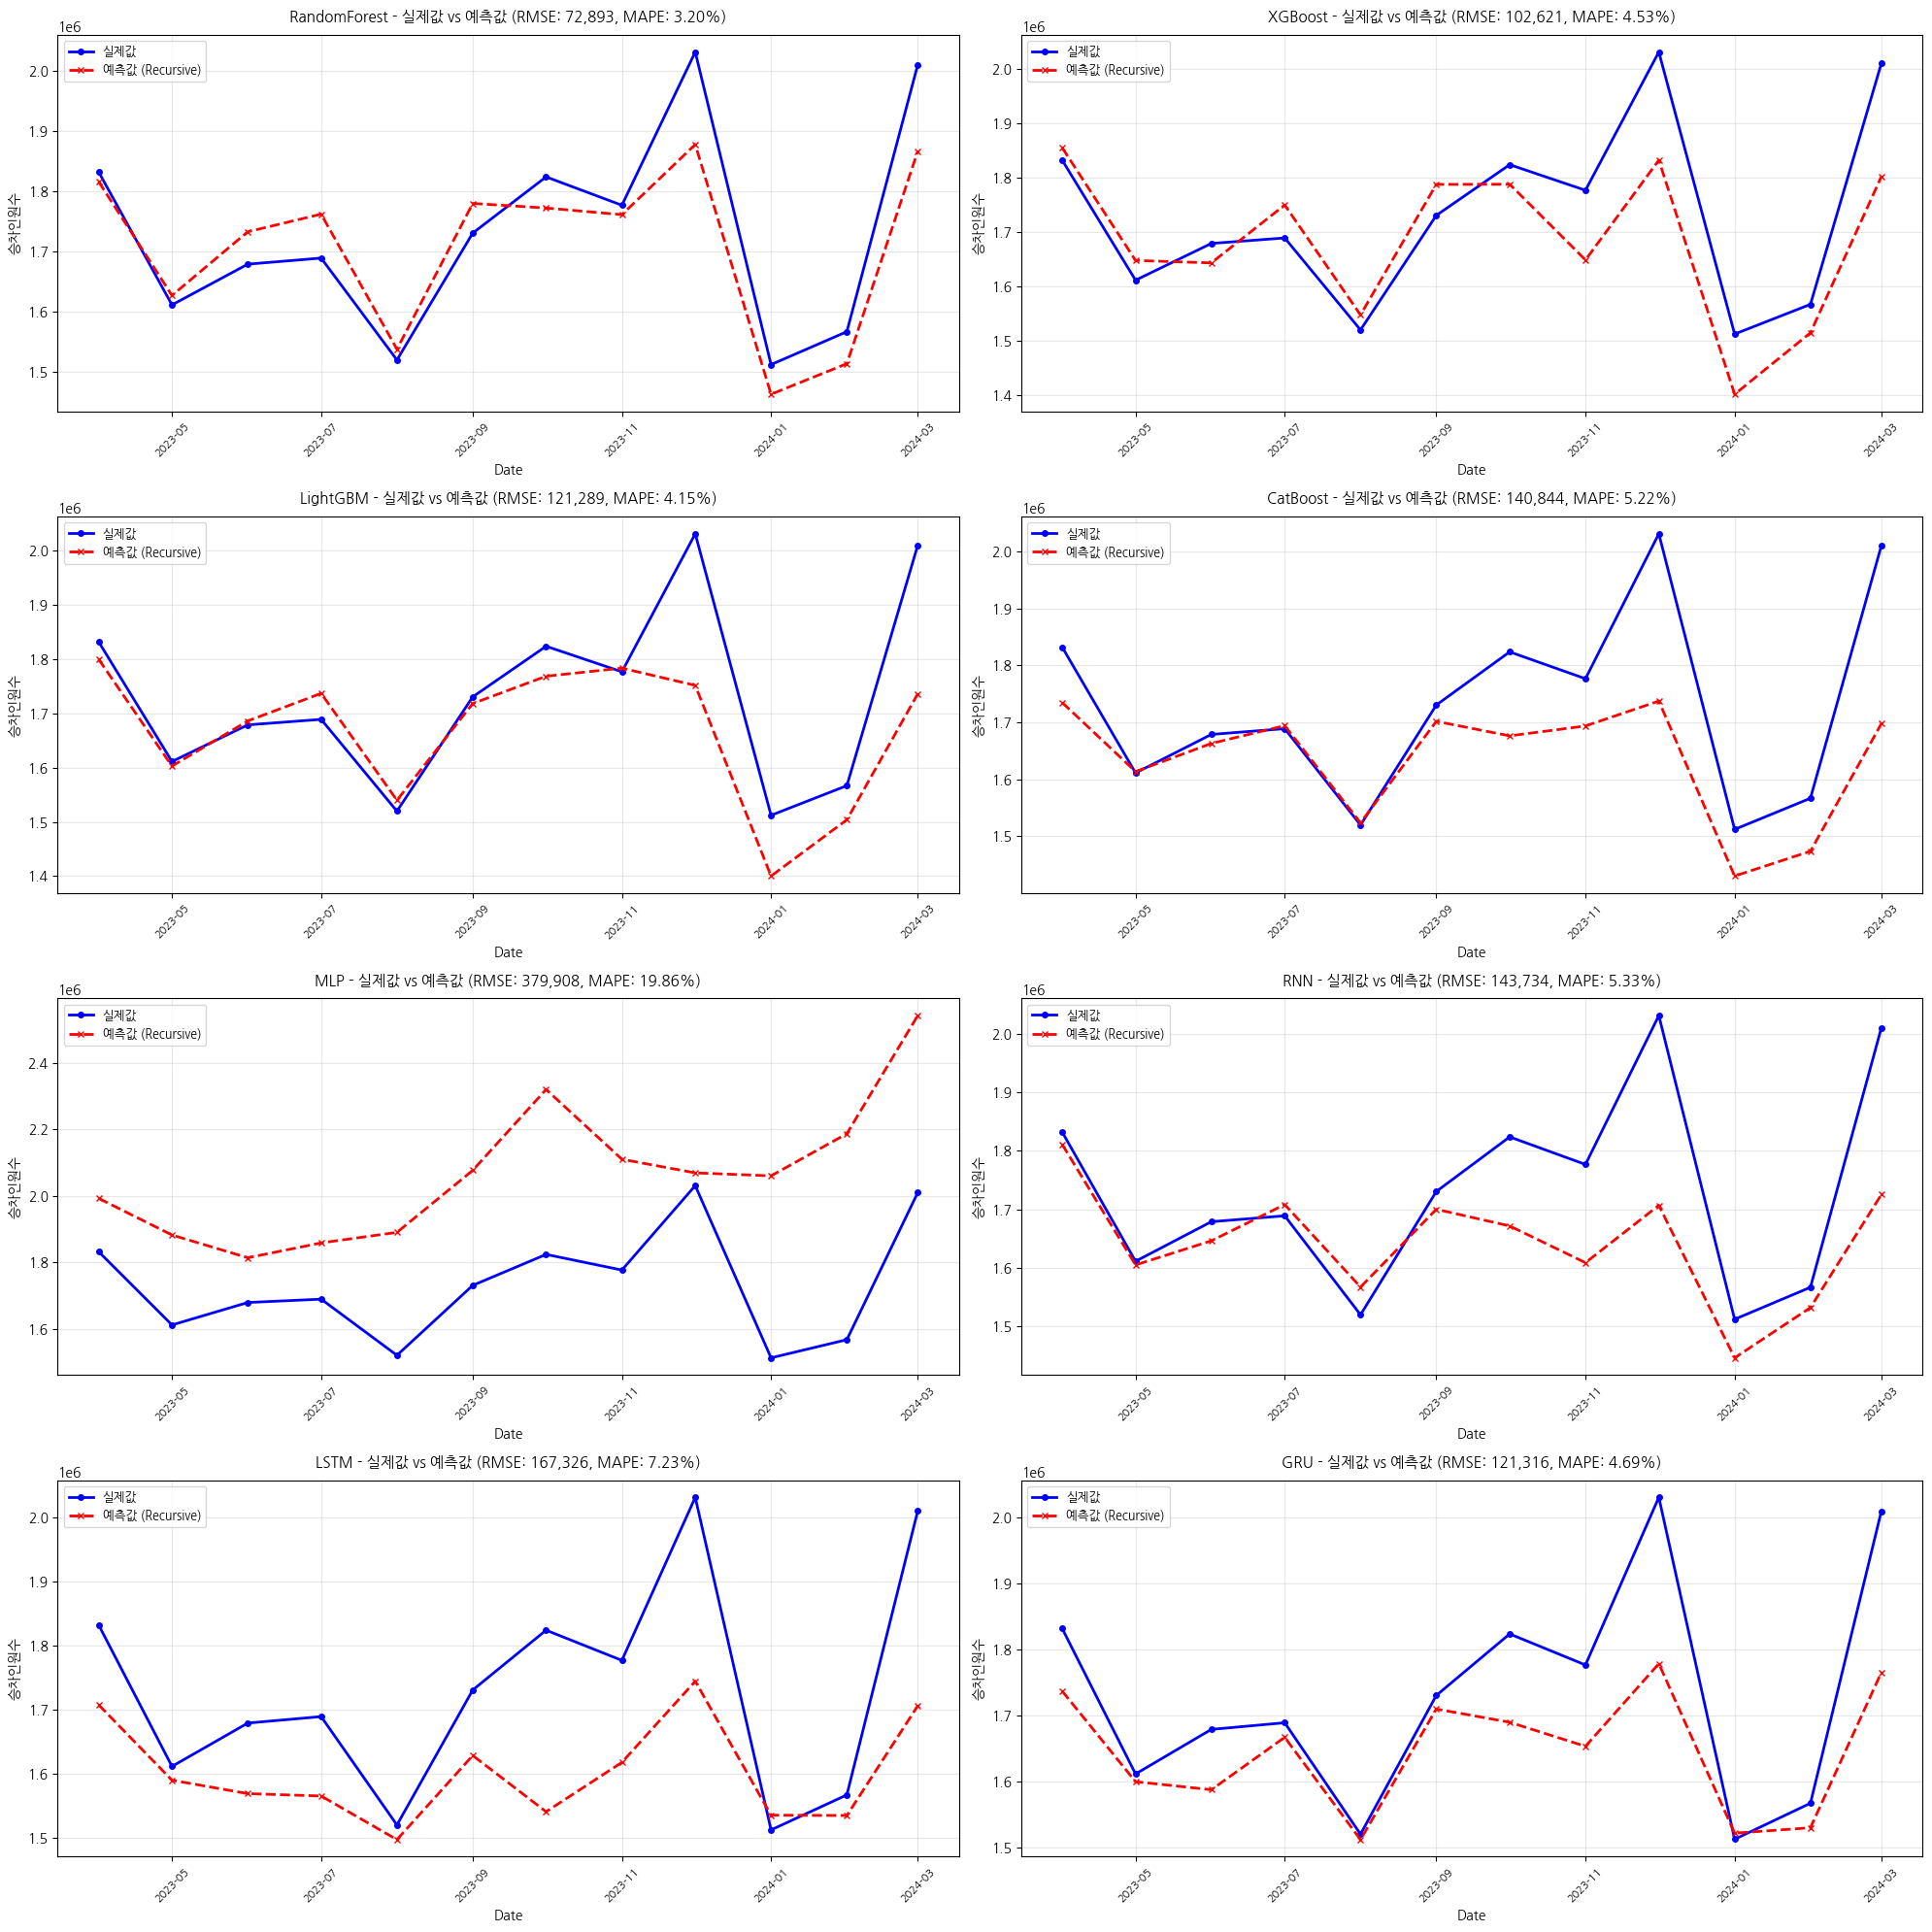

In [65]:
# Validation 기간의 날짜 정보
valid_dates = train_featured_clean.iloc[split_idx:]['Date'].values

# 시각화 (8개 모델 - 4x2)
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    ax = axes[idx]
    y_pred_recursive = predictions_dict[name]

    # 실제값 vs 예측값 (Recursive)
    ax.plot(valid_dates, y_valid.values, label='실제값', marker='o', linewidth=2, markersize=4, color='blue')
    ax.plot(valid_dates, y_pred_recursive, label='예측값 (Recursive)', marker='x', linewidth=2, markersize=4, color='red', linestyle='--')

    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('승차인원수', fontsize=10)
    ax.set_title(f'{name} - 실제값 vs 예측값 (RMSE: {results[name]["RMSE"]:,.0f}, MAPE: {results[name]["MAPE"]:.2f}%)',
                 fontsize=11, pad=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig(PROCESSED_DATA_PATH + 'validation_predictions_recursive.png', dpi=300, bbox_inches='tight')
print(f"✅ 시각화 저장 완료: {PROCESSED_DATA_PATH}validation_predictions_recursive.png")
plt.show()

## 10. Feature Importance (Tree 모델)

✅ Feature Importance 저장 완료: /mnt/c/Users/Admin/PycharmProjects/Demand-Forecasting-Dive/processed_data/feature_importance.png


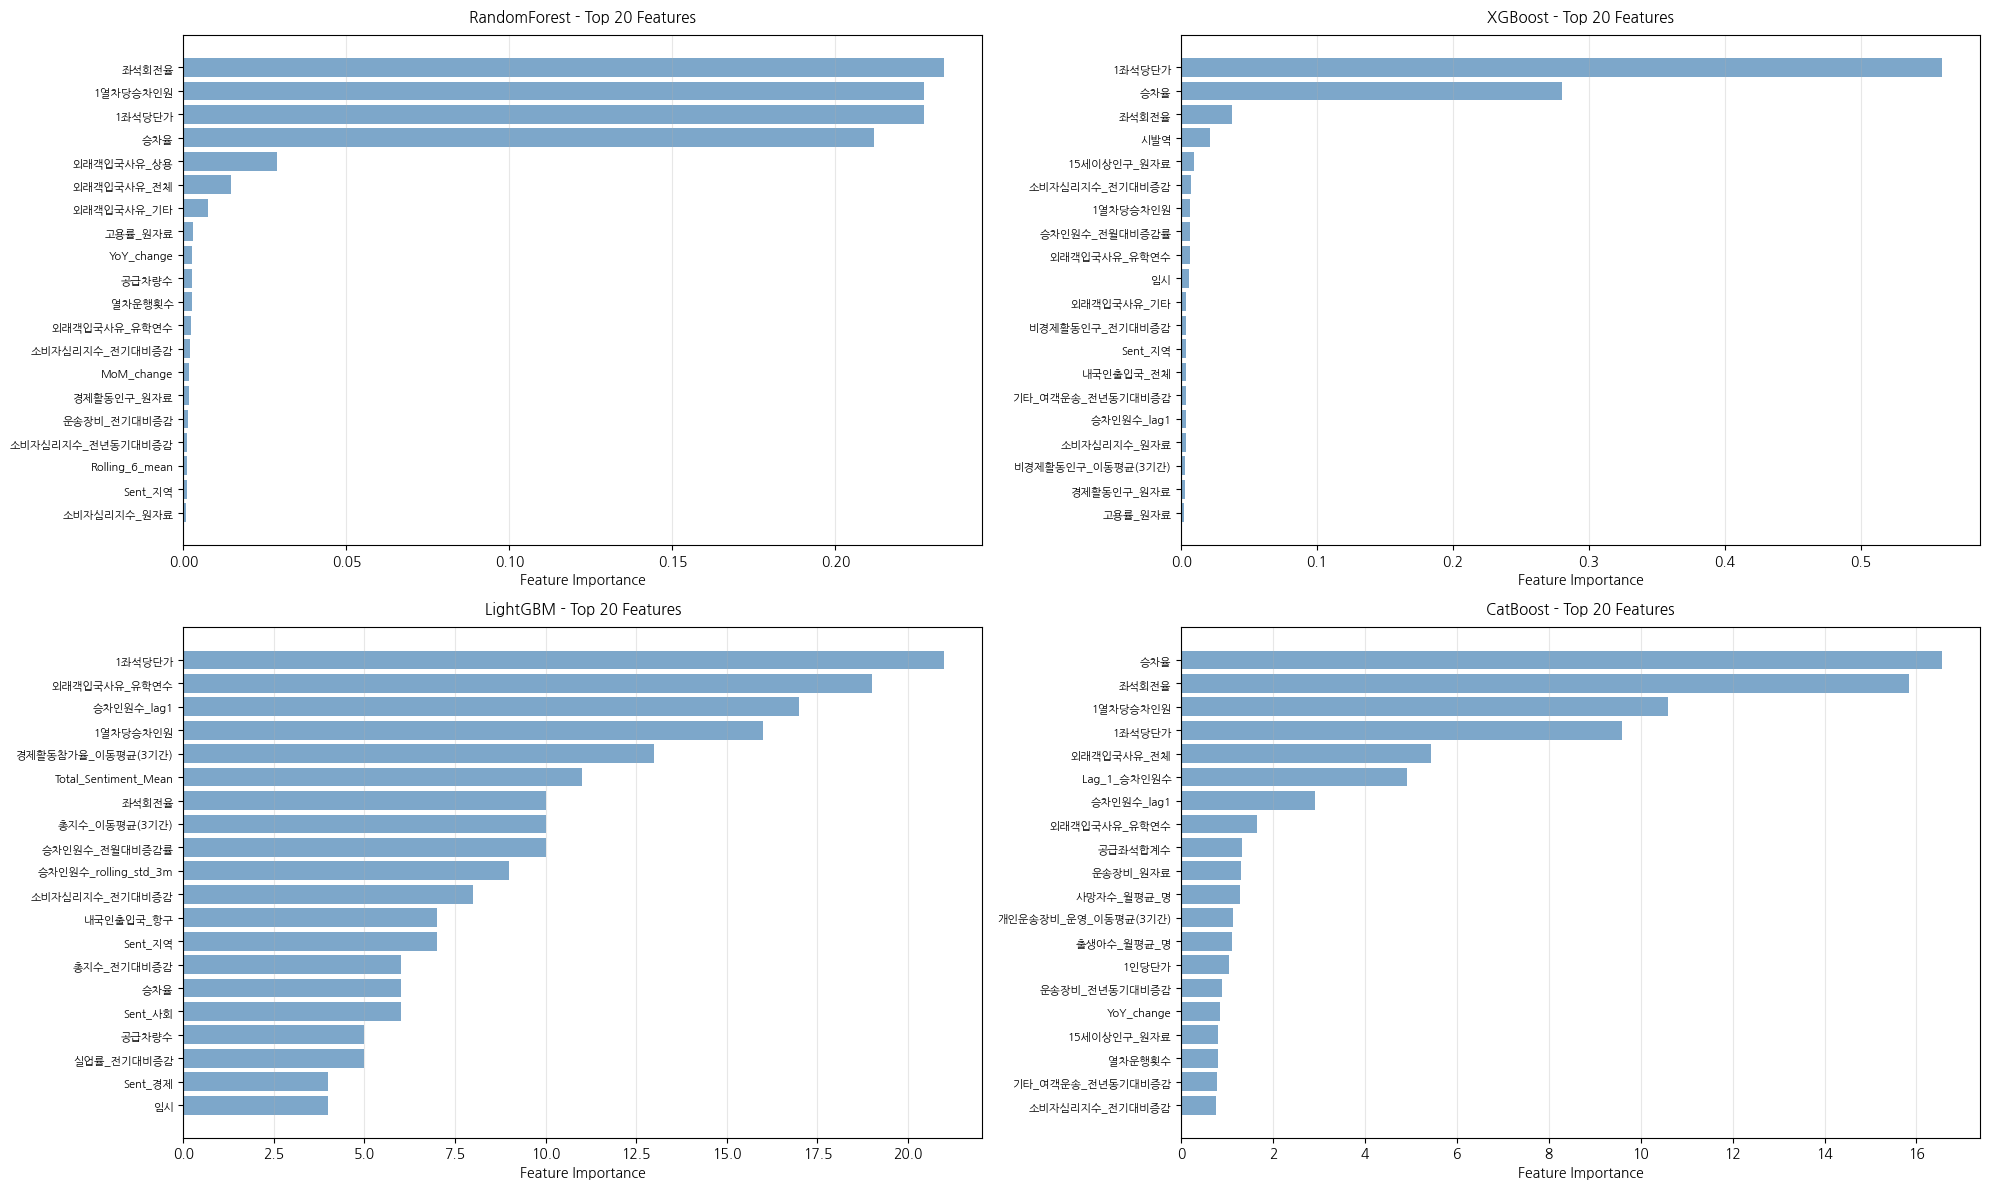

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

tree_models = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
for idx, name in enumerate(tree_models):
    ax = axes[idx]
    model = trained_models[name]

    # Feature importance 추출
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:20]  # Top 20

    # 시각화
    ax.barh(range(len(indices)), importances[indices], color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([feature_cols[i] for i in indices], fontsize=8)
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title(f'{name} - Top 20 Features', fontsize=11, pad=10)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(PROCESSED_DATA_PATH + 'feature_importance.png', dpi=300, bbox_inches='tight')
print(f"✅ Feature Importance 저장 완료: {PROCESSED_DATA_PATH}feature_importance.png")
plt.show()